<a href="https://colab.research.google.com/github/hossam-mmagdy/Python-Based-Fast-Screening-of-Molecular-Adsorption-Sites-on-Gold-Surfaces/blob/main/Python-Based-Fast-Screening-of-Molecular-Adsorption-Sites-on-Gold-Surfaces.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Install dependencies
!pip install ase
!pip install matplotlib
!pip install numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 30.8 MB/s eta 0:00:00


In [3]:
from math import cos, pi, sin
from ase import Atoms
from ase.build import add_adsorbate, fcc111
from ase.calculators.emt import EMT
from ase.constraints import FixLinearTriatomic
from ase.optimize import BFGS
from ase.visualize import view

zpos = cos(134.3 / 2.0 * pi / 180.0) * 1.197
xpos = sin(134.3 / 2.0 * pi / 180.0) * 1.19

print('xpos=', xpos, ' zpos=', zpos)

co2 = Atoms('COO', positions=[
    (-xpos + 1.2, 0, -zpos),
    (-xpos + 1.2, -1.1, -zpos),
    (-xpos + 1.2, +1.1, -zpos)
])

slab = fcc111('Au', size=(6, 6, 4), vacuum=2 * 10, orthogonal=True)
slab.center()

pos_shift = 5.0
add_adsorbate(slab, co2, height=1.5, position=(pos_shift, pos_shift))

view(slab)

slab.set_pbc((True, True, False))

d0 = co2.get_distance(-3, -2)
d1 = co2.get_distance(-3, -1)
d2 = co2.get_distance(-2, -1)
print("CO2 interatomic distances:", d0, d1, d2)

calc = EMT()
slab.calc = calc

slab.set_scaled_positions(slab.get_scaled_positions() % 1.0)

constraint = FixLinearTriatomic(triples=[(-2, -3, -1)])
slab.set_constraint(constraint)

print("Number of degrees of freedom =", slab.get_number_of_degrees_of_freedom())

print("running CO2@Au(111) geometry optimization:")

with BFGS(slab, trajectory='relaxation.traj') as dyn:
    dyn.run(fmax=0.05)

assert abs(slab.get_distance(-3, -2, mic=1) - d0) < 1e-9
assert abs(slab.get_distance(-3, -1, mic=1) - d1) < 1e-9
assert abs(slab.get_distance(-2, -1, mic=1) - d2) < 1e-9

print("assertion on CO2 interatomic distances:",
      abs(slab.get_distance(-3, -2, mic=1) - d0),
      abs(slab.get_distance(-3, -1, mic=1) - d1),
      abs(slab.get_distance(-2, -1, mic=1) - d2))

xpos= 1.0966143090665121  zpos= 0.46481893964041854
CO2 interatomic distances: 1.1 1.0999999999999996 2.1999999999999997
Number of degrees of freedom = 437
running CO2@Au(111) geometry optimization:
      Step     Time          Energy          fmax
BFGS:    0 22:18:25       22.709314       10.043823
BFGS:    1 22:18:25       20.436122        3.080129
BFGS:    2 22:18:25       19.360726        1.273491
BFGS:    3 22:18:25       18.635302        0.729640
BFGS:    4 22:18:25       18.359637        1.188844
BFGS:    5 22:18:25       18.214960        1.120586
BFGS:    6 22:18:26       18.094052        0.773644
BFGS:    7 22:18:26       17.989314        0.379396
BFGS:    8 22:18:26       17.909957        0.365556
BFGS:    9 22:18:26       17.865326        0.434828
BFGS:   10 22:18:26       17.828219        0.425049
BFGS:   11 22:18:26       17.777576        0.326081
BFGS:   12 22:18:26       17.738565        0.199596
BFGS:   13 22:18:27       17.721655        0.114341
BFGS:   14 22:18:27    

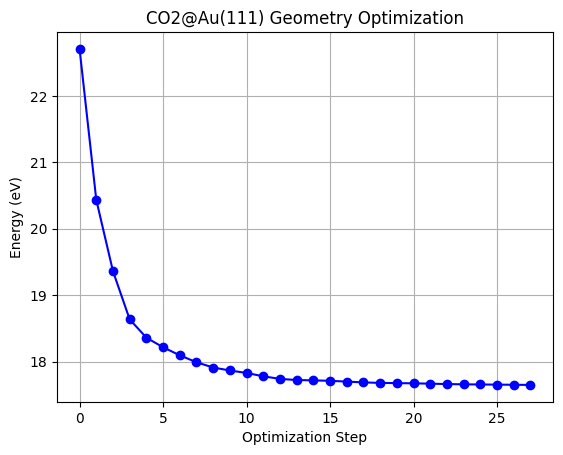

In [4]:
import matplotlib.pyplot as plt
from ase.io import read

traj = read('relaxation.traj@:')

energies = [atoms.get_potential_energy() for atoms in traj]
plt.plot(energies, 'b-o')
plt.xlabel('Optimization Step')
plt.ylabel('Energy (eV)')
plt.title('CO2@Au(111) Geometry Optimization')
plt.grid(True)
plt.savefig('optimization.png', dpi=150)
plt.show()


Running Au...
      Step     Time          Energy          fmax
BFGS:    0 22:18:48       15.016089       21.411561
BFGS:    1 22:18:48       10.666156        4.279734
BFGS:    2 22:18:48        9.803811        2.032036
BFGS:    3 22:18:48        9.032728        0.822727
BFGS:    4 22:18:48        8.765214        0.686298
BFGS:    5 22:18:48        8.628557        0.835463
BFGS:    6 22:18:49        8.561460        0.732681
BFGS:    7 22:18:49        8.513060        0.535451
BFGS:    8 22:18:49        8.470718        0.325359
BFGS:    9 22:18:49        8.437802        0.321372
BFGS:   10 22:18:49        8.419125        0.268330
BFGS:   11 22:18:49        8.400763        0.253476
BFGS:   12 22:18:49        8.372156        0.227856
BFGS:   13 22:18:49        8.349390        0.186358
BFGS:   14 22:18:49        8.335351        0.189083
BFGS:   15 22:18:49        8.324323        0.184863
BFGS:   16 22:18:50        8.313039        0.210305
BFGS:   17 22:18:50        8.299133        0.189977

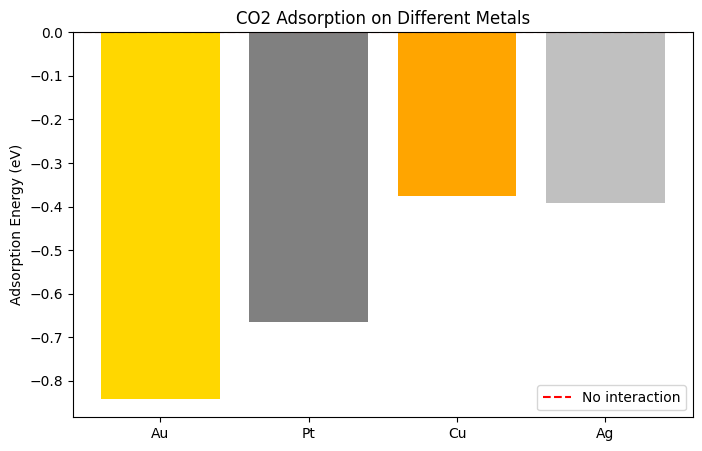

In [5]:
from math import cos, pi, sin
from ase import Atoms
from ase.build import add_adsorbate, fcc111
from ase.calculators.emt import EMT
from ase.constraints import FixLinearTriatomic
from ase.optimize import BFGS
import matplotlib.pyplot as plt
from ase.io import read

def run_adsorption(metal, height=1.5, size=(4, 4, 3)):
    zpos = cos(134.3 / 2.0 * pi / 180.0) * 1.197
    xpos = sin(134.3 / 2.0 * pi / 180.0) * 1.19
    co2 = Atoms('COO', positions=[
        (-xpos + 1.2, 0, -zpos),
        (-xpos + 1.2, -1.1, -zpos),
        (-xpos + 1.2, +1.1, -zpos)
    ])

    co2.calc = EMT()
    E_co2 = co2.get_potential_energy()

    slab_clean = fcc111(metal, size=size, vacuum=15, orthogonal=True)
    slab_clean.calc = EMT()
    E_slab = slab_clean.get_potential_energy()

    slab = fcc111(metal, size=size, vacuum=15, orthogonal=True)
    add_adsorbate(slab, co2, height, 'fcc')
    slab.calc = EMT()

    constraint = FixLinearTriatomic(triples=[(-2, -3, -1)])
    slab.set_constraint(constraint)

    with BFGS(slab, trajectory=f'{metal}_co2.traj') as dyn:
        dyn.run(fmax=0.05)

    E_final = slab.get_potential_energy()
    E_ads = E_final - E_slab - E_co2

    return {
        'metal': metal,
        'E_adsorption': E_ads,
        'E_final': E_final,
        'E_slab': E_slab,
        'E_co2': E_co2
    }

metals = ['Au', 'Pt', 'Cu', 'Ag']
results = []

for metal in metals:
    print(f"\n{'='*40}")
    print(f"Running {metal}...")
    result = run_adsorption(metal)
    results.append(result)
    print(f"Adsorption Energy: {result['E_adsorption']:.3f} eV")

print(f"\n{'='*50}")
print("SUMMARY - Adsorption Energies")
print(f"{'Metal':<10} {'E_ads (eV)':<15} {'Strength'}")
print("-" * 50)
for r in results:
    strength = "Strong" if r['E_adsorption'] < -0.5 else "Weak" if r['E_adsorption'] < 0 else "Repulsive"
    print(f"{r['metal']:<10} {r['E_adsorption']:<15.3f} {strength}")

metals_list = [r['metal'] for r in results]
energies_list = [r['E_adsorption'] for r in results]

plt.figure(figsize=(8, 5))
plt.bar(metals_list, energies_list, color=['gold', 'gray', 'orange', 'silver'])
plt.axhline(y=0, color='r', linestyle='--', label='No interaction')
plt.ylabel('Adsorption Energy (eV)')
plt.title('CO2 Adsorption on Different Metals')
plt.legend()
plt.savefig('adsorption_comparison.png', dpi=150)
plt.show()